In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    roc_auc_score, roc_curve, 
    average_precision_score, precision_recall_curve
)
import xgboost as xgb
import optuna

print(f"XGBoost version: {xgb.__version__}")
print(f"GPU Support: {xgb.build_info()['USE_CUDA']}")
print(f"Optuna version: {optuna.__version__}")

XGBoost version: 3.3.0
GPU Support: True
Optuna version: 4.9.0


In [2]:
# Cargar dataset
df = pd.read_csv('../../Dataset/default of credit card clients.csv', sep=',', skiprows=1)

# Limpieza inicial
if 'default payment next month' in df.columns:
    df.rename(columns={'default payment next month': 'default'}, inplace=True)
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

print(f"\n📊 Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas")
print(f"📈 Distribución de clases:")
print(df['default'].value_counts())
print(f"\nTasa de incumplimiento: {df['default'].mean()*100:.2f}%")

display(df.head())


📊 Dataset cargado: 30000 registros, 24 columnas
📈 Distribución de clases:
default
0    23364
1     6636
Name: count, dtype: int64

Tasa de incumplimiento: 22.12%


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
# ============================================
# MÓDULO 2: FEATURE ENGINEERING
# ============================================

# Ratios de Utilización de Crédito
for i in range(1, 7):
    df[f'UTILIZATION_{i}'] = df[f'BILL_AMT{i}'] / (df['LIMIT_BAL'] + 1)

# Ratios de Pago (porcentaje de deuda pagada)
for i in range(1, 7):
    df[f'PAY_RATIO_{i}'] = df[f'PAY_AMT{i}'] / (df[f'BILL_AMT{i}'] + 1)

# Estadísticas Históricas de Pagos
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df['PAY_MEAN'] = df[pay_cols].mean(axis=1)   # Retraso promedio
df['PAY_MAX'] = df[pay_cols].max(axis=1)     # Peor retraso histórico
df['PAY_MIN'] = df[pay_cols].min(axis=1)     # Mejor pago histórico
df['PAY_STD'] = df[pay_cols].std(axis=1)     # Volatilidad (muy predictivo)

# Tendencias de Deuda
df['DEBT_TREND'] = df['BILL_AMT1'] - df['BILL_AMT6']  # ¿Deuda creciente?
df['DEBT_TREND_PCT'] = (df['BILL_AMT1'] - df['BILL_AMT6']) / (df['BILL_AMT6'] + 1)

# Cambios mensuales en estado de pago
for i in range(2, 7):
    if i == 2:
        df[f'PAY_DELTA_{i}'] = df['PAY_0'] - df[f'PAY_{i}']
    else:
        df[f'PAY_DELTA_{i}'] = df[f'PAY_{i-1}'] - df[f'PAY_{i}']

delta_cols = [f'PAY_DELTA_{i}' for i in range(2, 7)]
df['PAY_DELTA_MEAN'] = df[delta_cols].mean(axis=1)

# Estadísticas de montos de pago
pay_amt_cols = [f'PAY_AMT{i}' for i in range(1, 7)]
df['PAY_AMT_MEAN'] = df[pay_amt_cols].mean(axis=1)
df['PAY_AMT_STD'] = df[pay_amt_cols].std(axis=1)
df['PAY_AMT_TOTAL'] = df[pay_amt_cols].sum(axis=1)

print(f"✅ Nuevas características creadas: {df.shape[1] - 24} variables adicionales")
print(f"📊 Total de columnas: {df.shape[1]}")
print(f"\nEjemplo de nuevas variables:")
new_features = [col for col in df.columns if any(x in col for x in ['UTILIZATION', 'PAY_RATIO', 'PAY_MEAN', 'DEBT_TREND'])]
display(df[new_features[:10]].head(3))

✅ Nuevas características creadas: 27 variables adicionales
📊 Total de columnas: 51

Ejemplo de nuevas variables:


,UTILIZATION_1,UTILIZATION_2,UTILIZATION_3,UTILIZATION_4,UTILIZATION_5,UTILIZATION_6,PAY_RATIO_1,PAY_RATIO_2,PAY_RATIO_3,PAY_RATIO_4
0,0.195640,0.155092,0.034448,0.000000,0.000000,0.000000,0.000000,0.222043,0.000000,0.000000
1,0.022350,0.014375,0.022350,0.027266,0.028791,0.027175,0.000000,0.579374,0.372717,0.305530
2,0.324874,0.155854,0.150654,0.159232,0.166087,0.172765,0.051915,0.106929,0.073746,0.069774


In [4]:
# ============================================
# MÓDULO 3: PREPROCESAMIENTO
# ============================================

# Separar variables
X = df.drop('default', axis=1)
y = df['default']

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0) 

# División estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Calcular peso para desbalance de clases
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

In [5]:
print(f"Entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[1]} características)")
print(f"Prueba:        {X_test.shape[0]} muestras")
print(f"\nDesbalance de clases:")
print(f"  - Cumple (0):     {neg} ({neg/len(y_train)*100:.1f}%)")
print(f"  - Incumple (1):   {pos} ({pos/len(y_train)*100:.1f}%)")
print(f"\n⚖️  Scale Pos Weight: {scale_pos_weight:.2f}")

Entrenamiento: 24000 muestras (50 características)
Prueba:        6000 muestras

Desbalance de clases:
  - Cumple (0):     18691 (77.9%)
  - Incumple (1):   5309 (22.1%)

⚖️  Scale Pos Weight: 3.52


## Módulo 4: Optimización de Hiperparámetros

Usamos **Optuna** para buscar automáticamente la mejor combinación de hiperparámetros mediante optimización bayesiana, maximizando el **PR-AUC** (métrica crítica para datos desbalanceados).

**Espacio de búsqueda:**
- Regularización: `gamma`, `min_child_weight`, `reg_alpha`, `reg_lambda`
- Complejidad: `max_depth`, `n_estimators`, `learning_rate`
- Muestreo: `subsample`, `colsample_bytree`

In [6]:
# ============================================
# MÓDULO 4: OPTIMIZACIÓN BAYESIANA (OPTUNA)
# ============================================

def objective(trial):
    """Función objetivo para Optuna"""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1500),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'min_child_weight': trial.suggest_float('min_child_weight', 1, 15),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': scale_pos_weight,
        'tree_method': 'hist',
        'device': 'cuda',
        'eval_metric': 'aucpr',
        'random_state': 42,
        'verbosity': 1
    }
    
    # Validación cruzada estratificada (3 folds)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    pr_auc_scores = []
    
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = xgb.XGBClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        
        preds = model.predict_proba(X_val)[:, 1]
        pr_auc = average_precision_score(y_val, preds)
        pr_auc_scores.append(pr_auc)
        
    return np.mean(pr_auc_scores)

In [7]:
# Configurar y ejecutar Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction='maximize', 
    study_name="XGBoost_Credit_Risk_Optimization"
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"🏆 Mejor PR-AUC: {study.best_value:.4f}")
print(f"\n📋 Mejores hiperparámetros:")
for param, value in study.best_params.items():
    print(f"  - {param}: {value}")

  0%|          | 0/50 [00:00<?, ?it/s]

🏆 Mejor PR-AUC: 0.5652

📋 Mejores hiperparámetros:
  - n_estimators: 580
  - max_depth: 5
  - learning_rate: 0.011558660861218352
  - subsample: 0.7950069747033663
  - colsample_bytree: 0.6197635576001502
  - gamma: 2.33318590589498
  - min_child_weight: 1.9291373370605507
  - reg_alpha: 3.998483264245948e-08
  - reg_lambda: 0.10651298773291548


In [8]:
# Visualización de convergencia
fig = optuna.visualization.plot_optimization_history(study)
fig.show()

In [11]:
# ============================================
# MÓDULO 5: ENTRENAMIENTO DEL MEJOR MODELO
# ============================================

best_params = study.best_params.copy()
best_params.update({
    'tree_method': 'hist',
    'device': 'cuda',
    'eval_metric': 'aucpr',
    'random_state': 42,
    'verbosity': 1
})

champion_model = xgb.XGBClassifier(**best_params)
champion_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=1
)

print(f"🌲 Número de árboles utilizados: {champion_model.n_estimators}")

[0]	validation_0-aucpr:0.51911
[1]	validation_0-aucpr:0.54081
[2]	validation_0-aucpr:0.54009
[3]	validation_0-aucpr:0.54845
[4]	validation_0-aucpr:0.54860
[5]	validation_0-aucpr:0.54974
[6]	validation_0-aucpr:0.55272
[7]	validation_0-aucpr:0.55407
[8]	validation_0-aucpr:0.55547
[9]	validation_0-aucpr:0.55586
[10]	validation_0-aucpr:0.55616
[11]	validation_0-aucpr:0.55642
[12]	validation_0-aucpr:0.55411
[13]	validation_0-aucpr:0.55428
[14]	validation_0-aucpr:0.55411
[15]	validation_0-aucpr:0.55447
[16]	validation_0-aucpr:0.55478
[17]	validation_0-aucpr:0.55481
[18]	validation_0-aucpr:0.55512
[19]	validation_0-aucpr:0.55532
[20]	validation_0-aucpr:0.55498
[21]	validation_0-aucpr:0.55604
[22]	validation_0-aucpr:0.55614
[23]	validation_0-aucpr:0.55642
[24]	validation_0-aucpr:0.55573
[25]	validation_0-aucpr:0.55524
[26]	validation_0-aucpr:0.55577
[27]	validation_0-aucpr:0.55556
[28]	validation_0-aucpr:0.55639
[29]	validation_0-aucpr:0.55727
[30]	validation_0-aucpr:0.55722
[31]	validation_0-

In [12]:
# ============================================
# MÓDULO 6: THRESHOLD TUNING
# ============================================

# Obtener probabilidades
y_pred_prob = champion_model.predict_proba(X_test)[:, 1]

# Encontrar umbral óptimo
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
f1_scores = 2 * recall * precision / (recall + precision + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"Umbral por defecto:     0.500")
print(f"Umbral óptimo:          {best_threshold:.3f}")
print(f"\n💡 Interpretación:")
print(f"   Si probabilidad ≥ {best_threshold:.3f} → Predice Incumplimiento")
print(f"   Si probabilidad < {best_threshold:.3f} → Predice Cumplimiento")

Umbral por defecto:     0.500
Umbral óptimo:          0.271

💡 Interpretación:
   Si probabilidad ≥ 0.271 → Predice Incumplimiento
   Si probabilidad < 0.271 → Predice Cumplimiento


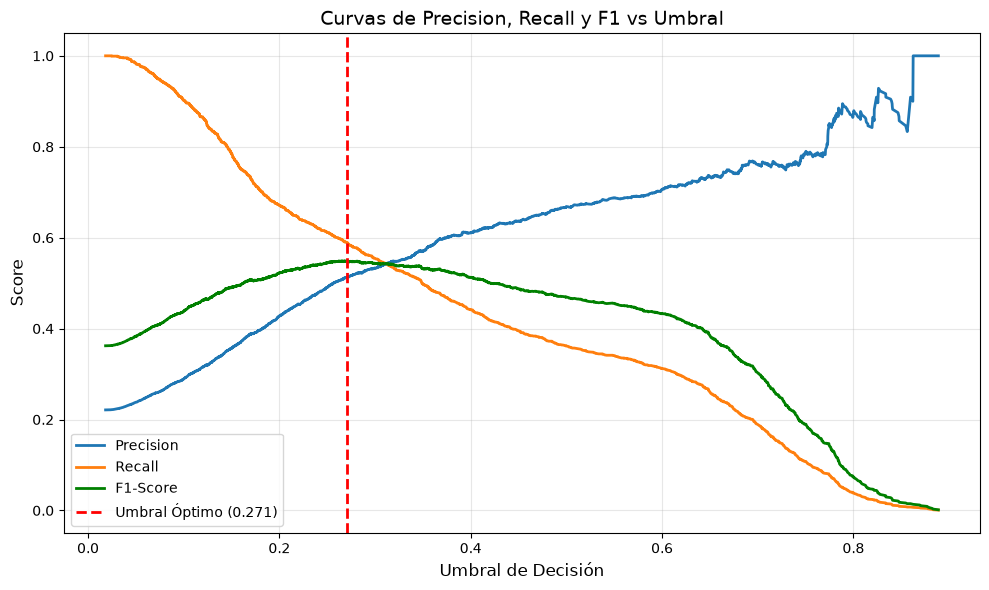

In [13]:
# Aplicar umbral óptimo
y_pred_optimized = (y_pred_prob >= best_threshold).astype(int)

# Visualización del umbral
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, precision[:-1], label='Precision', linewidth=2)
ax.plot(thresholds, recall[:-1], label='Recall', linewidth=2)
ax.plot(thresholds, f1_scores[:-1], label='F1-Score', linewidth=2, color='green')
ax.axvline(x=best_threshold, color='red', linestyle='--', 
           label=f'Umbral Óptimo ({best_threshold:.3f})', linewidth=2)
ax.set_xlabel('Umbral de Decisión', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Curvas de Precision, Recall y F1 vs Umbral', fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

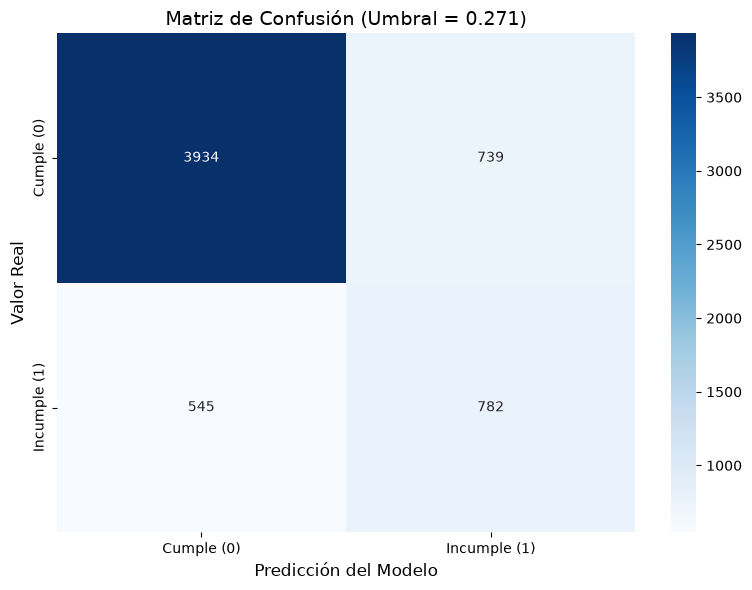

In [14]:
# ============================================
# MÓDULO 7: EVALUACIÓN COMPLETA
# ============================================

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_optimized)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cumple (0)', 'Incumple (1)'], 
            yticklabels=['Cumple (0)', 'Incumple (1)'])
plt.title(f'Matriz de Confusión (Umbral = {best_threshold:.3f})', fontsize=14)
plt.ylabel('Valor Real', fontsize=12)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
print(classification_report(y_test, y_pred_optimized, 
                          target_names=['Cumple (0)', 'Incumple (1)']))

              precision    recall  f1-score   support

  Cumple (0)       0.88      0.84      0.86      4673
Incumple (1)       0.51      0.59      0.55      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.72      0.70      6000
weighted avg       0.80      0.79      0.79      6000



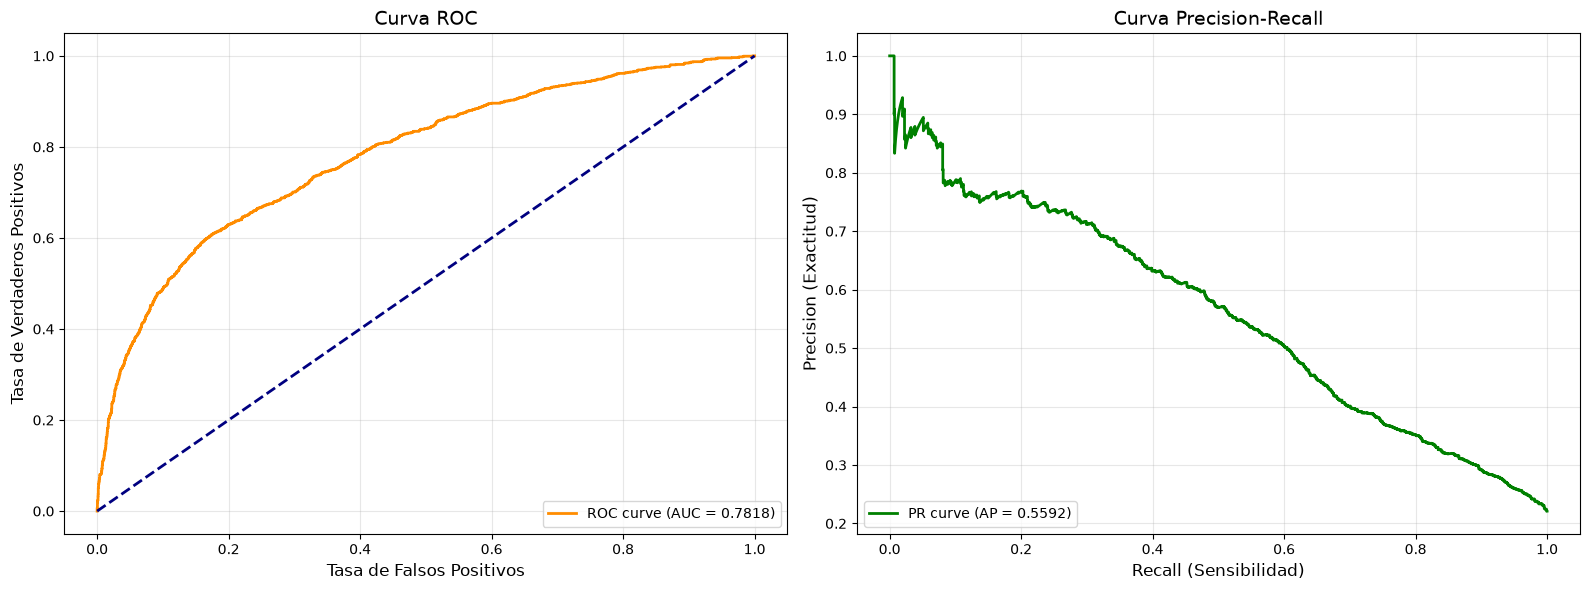

ROC-AUC:              0.7818
PR-AUC:               0.5592
Umbral Óptimo:        0.271


In [19]:
# Curvas ROC y Precision-Recall
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)
ax1.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlabel('Tasa de Falsos Positivos', fontsize=12)
ax1.set_ylabel('Tasa de Verdaderos Positivos', fontsize=12)
ax1.set_title('Curva ROC', fontsize=14)
ax1.legend(loc="lower right", fontsize=10)
ax1.grid(alpha=0.3)

# Curva Precision-Recall
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_prob)
pr_auc = average_precision_score(y_test, y_pred_prob)
ax2.plot(recall_curve, precision_curve, color='green', lw=2, 
         label=f'PR curve (AP = {pr_auc:.4f})')
ax2.set_xlabel('Recall (Sensibilidad)', fontsize=12)
ax2.set_ylabel('Precision (Exactitud)', fontsize=12)
ax2.set_title('Curva Precision-Recall', fontsize=14)
ax2.legend(loc="lower left", fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ROC-AUC:              {roc_auc:.4f}")
print(f"PR-AUC:               {pr_auc:.4f}")
print(f"Umbral Óptimo:        {best_threshold:.3f}")

<Figure size 1200x1000 with 0 Axes>

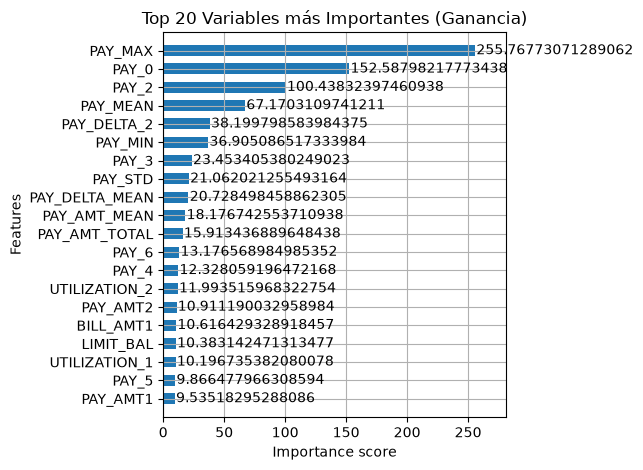

In [20]:
# ============================================
# MÓDULO 8: INTERPRETABILIDAD
# ============================================

# Importancia por ganancia
plt.figure(figsize=(12, 10))
xgb.plot_importance(
    champion_model, 
    max_num_features=20, 
    importance_type='gain',
    title='Top 20 Variables más Importantes (Ganancia)',
    height=0.6
)
plt.tight_layout()
plt.show()